# Reproduction: Drone phenotyping of daily floral opening in lettuce — SVM floral-pixel classification and Bayesian peak-opening-time inference

**Paper:** Han, R. et al. (2020) *Drone phenotyping and machine learning enable discovery of loci regulating daily floral opening in lettuce.* bioRxiv 2020.07.16.206953. https://doi.org/10.1101/2020.07.16.206953

**Author code:** https://github.com/rkbhan/FloralOpening @ commit `9069822e38b60554076988c3b2516d5c7b02caf8` (R, MIT-free? see license note below).

**Scope (partial demonstration):** the paper's two phenotype-extraction stages on the authors' bundled example data:
1. SVM classification of floral / vegetative / ground pixels from HSV features (`FOH_GitHub_files/Labeled_pixel_samples.csv`), including the 5-method comparison and the final model.
2. Bayesian inference of peak floral opening time (FOT) per plot from standardized floral pixel counts (`FOH_GitHub_files/MLoutput_std_pxl_ct.csv`) using the paper's Gaussian-like curve model fitted by MCMC (`rethinking::ulam`).

**Not in scope:** orthomosaic reconstruction (Pix4DMapper Pro), plot polygon delineation (ArcMap), genotyping and QTL mapping (scripts not published), the 8.8 GB raw imagery (HydroShare) and SRA reads.

**Execution status: validated on a fresh Google Colab CPU runtime (all cells executed top-to-bottom).**

**Runtime to select:** **CPU** (Runtime > Change runtime type > CPU). No GPU is used anywhere in the method.

**日本語要約:** このノートブックは、レタスの花開花時刻をドローン画像から抽出する2段階パイプライン（SVMによる花画素分類＋ベイズMCMCによるピーク開花時刻推定）を、著者公開のRコードと同梱データで再現します。CPUランタイムで動作し、全セル実行済みです。商用ソフト（オルソ画像生成・プロット区画切り出し）とQTL解析は対象外です。

**License note:** the repository has no LICENSE file; this notebook quotes the author's own analysis code with attribution and a pinned commit for reproducibility.

## How to run

Select a **CPU** runtime, then *Runtime > Run all*. Expected wall time on a free Colab CPU VM is roughly **30–50 minutes** (measured on validation: R package install ≈ 5–10 min via Linux binaries, ML stage ≈ 5 min, MCMC stage ≈ 10–20 min). Downloads are two small CSVs (≈ 480 KB total).

The notebook is a Python notebook only because the Colab CLI's R-kernel path is unverified; every scientific step is the **authors' own R code**, written to `/content` and executed with `Rscript`. Python is only the launcher.

### Environment check

We first confirm the Colab VM has R available and record its version.

In [ ]:
import subprocess, pathlib
R = r'''cat(R.version.string, "\n")'''
pathlib.Path('/content/r_version.R').write_text(R)
p = subprocess.run(['Rscript', '/content/r_version.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript r_version failed with rc=' + str(p.returncode))


R version 4.6.1 (2026-06-24) 



### Install the R packages used by the authors

The authors used `ggplot2`, `GGally`, `gridExtra`, `caret`, `kernlab`, `data.table` (SVM stage) and `rethinking`+`rstan` (Bayesian stage). We install Linux **binary** builds from the Posit Package Manager (jammy) to keep setup in minutes. The authors called the Bayesian model through `rethinking::ulam`, which translates the formula into a Stan program and samples it with **rstan** — the `rethinking` front-end no longer installs on current R 4.6 (rethinking 2.42 now requires `cmdstanr`; older CRAN versions are unavailable), so Stage 2 uses the identical Stan model/priors via `rstan` directly (see the Stage 2 note for the exact translation).

In [ ]:
import subprocess, pathlib
R = r'''options(repos = c(P3M = 'https://packagemanager.posit.co/cran/__linux__/jammy/latest'), Ncpus = 4)
install.packages(c('ggplot2','GGally','gridExtra','kernlab','caret','randomForest','data.table','tidyr','rstan','StanHeaders'))
cat('INSTALL_DONE\n')
cat('rstan', as.character(packageVersion('rstan')), '\n')'''
pathlib.Path('/content/install_r.R').write_text(R)
p = subprocess.run(['Rscript', '/content/install_r.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript install_r failed with rc=' + str(p.returncode))


begin installing package ‘globals’
begin installing package ‘listenv’
begin installing package ‘parallelly’
begin installing package ‘shape’
* installing *source* package ‘shape’ ...
** this is package ‘shape’ version ‘1.4.6.1’
** package ‘shape’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** demo
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (shape)
begin installing package ‘progressr’
* installing *source* package ‘listenv’ ...
** this is package ‘listenv’ version ‘1.0.0’
** package ‘listenv’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** he

### Acquire the authors' bundled example data

Both CSVs are bundled in the pinned repository. We download them **inside Colab** from the pinned commit's raw URLs and verify their byte sizes against the GitHub tree metadata recorded for commit `9069822` (440,184 and 41,665 bytes). No dataset bytes are handled outside Colab.

In [ ]:
import urllib.request, pathlib
BASE = 'https://raw.githubusercontent.com/rkbhan/FloralOpening/9069822e38b60554076988c3b2516d5c7b02caf8/FOH_GitHub_files'
expected = {'Labeled_pixel_samples.csv': 440184, 'MLoutput_std_pxl_ct.csv': 41665}
for name, size in expected.items():
    dest = pathlib.Path('/content') / name
    urllib.request.urlretrieve(f'{BASE}/{name}', dest)
    actual = dest.stat().st_size
    print(f'{name}: {actual} bytes (expected {size})', 'OK' if actual == size else 'SIZE MISMATCH')
    assert actual == size, 'byte-size mismatch for ' + name


Labeled_pixel_samples.csv: 440184 bytes (expected 440184) OK


MLoutput_std_pxl_ct.csv: 41665 bytes (expected 41665) OK


## Input preview — labeled HSV pixel samples

Before any modeling we inspect the actual input: 4,807 pixels labeled `floral`, `vegetative`, `ground` with their H/S/V readouts, sampled by the authors from 7 daily time points (9am–4pm).

This R chunk prints the table dimensions, the label balance, the hourly counts, and a few rows.

In [ ]:
import subprocess, pathlib
R = r'''allpix_plot = read.csv('/content/Labeled_pixel_samples.csv')
cat('dim:', dim(allpix_plot), '\n')
cat('columns:', paste(colnames(allpix_plot), collapse=', '), '\n')
print(table(allpix_plot$label))
print(table(allpix_plot$hour))
head(allpix_plot)'''
pathlib.Path('/content/preview_pixels.R').write_text(R)
p = subprocess.run(['Rscript', '/content/preview_pixels.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript preview_pixels failed with rc=' + str(p.returncode))


dim: 4807 10 
columns: X_Coord, Y_Coord, B, G, R, H, S, V, label, hour 

    floral     ground vegetative 
      1569       1557       1681 

  9  10  11  12  13  15  16 
462 900 902 900 914 369 360 
  X_Coord Y_Coord         B         G         R         H         S        V
1    4813    1625 0.5966622 0.9999999 0.7891368  91.36773 0.4033377 255.0000
2    4804    1627 0.5748691 0.9273890 0.8082794  80.27282 0.3801209 236.4842
3    4831    1626 0.5876158 0.9999999 0.6981598 103.91637 0.4123841 255.0000
4    4839    1639 0.4316942 0.9433950 0.5801296 102.59506 0.5424035 240.5657
5    4835    1634 0.3962189 0.8365424 0.4878728 107.51093 0.5263612 213.3183
6    4826    1638 0.4853387 0.8552468 0.5399523 111.14153 0.4325162 218.0880
   label hour
1 floral    9
2 floral    9
3 floral    9
4 floral    9
5 floral    9
6 floral    9



### HSV distributions by class (authors' figure, chunk 3 of FOH_Machine_Learning)

The authors' `ggpairs` scatter/histogram matrix of H, S, V colored by class; this is the input the SVM will learn from.

In [ ]:
import subprocess, pathlib
R = r'''library(ggplot2); library(GGally)
allpix_plot = read.csv('/content/Labeled_pixel_samples.csv')
allpix_pairs = allpix_plot[, c('H','S','V','label')]
p = ggpairs(allpix_pairs, aes(colour = label, alpha = 0.4), title = 'HSV by pixel class')
for (i in 1:p$nrow) for (j in 1:p$ncol) {
  p[i,j] <- p[i,j] +
    scale_fill_manual(values = c('gold','tan4','forestgreen')) +
    scale_color_manual(values = c('gold','tan4','forestgreen'))
}
ggsave('/content/hsv_pairs.png', p, width = 12, height = 12, dpi = 110)
cat('saved\n')'''
pathlib.Path('/content/hsv_pairs.R').write_text(R)
p = subprocess.run(['Rscript', '/content/hsv_pairs.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript hsv_pairs failed with rc=' + str(p.returncode))


saved



Display the saved plot as the cell's PNG output.

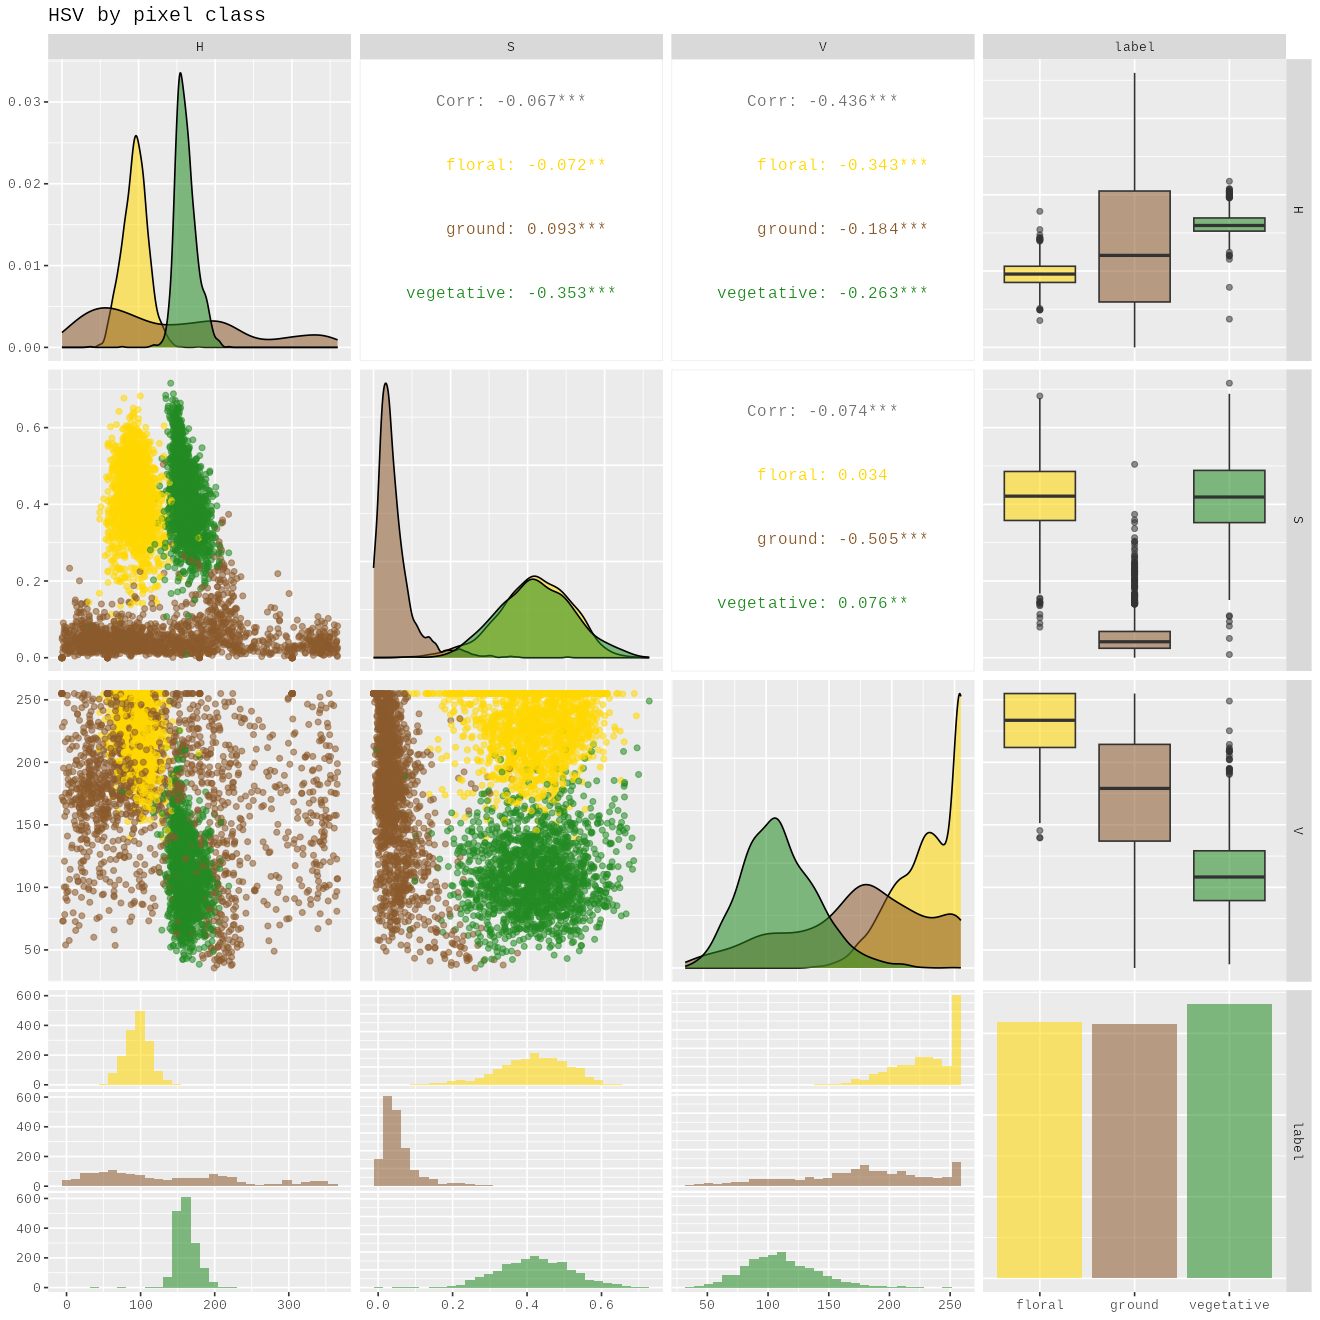

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/hsv_pairs.png'))

## Stage 1 — Machine-learning identification of floral pixels (authors' FOH_Machine_Learning)

### Baseline: naive hard-threshold classification (authors' "human learning" chunk)

The authors first show why simple thresholding is insufficient: pixels within the 1–99% quantile range of each HSV axis of the floral class are called floral. Their recorded result: recall 0.7616 for floral, false-positive rate 0.0038. We reproduce exactly this computation.

In [ ]:
import subprocess, pathlib
R = r'''allpix_plot = read.csv('/content/Labeled_pixel_samples.csv')
floralpix = allpix_plot[allpix_plot$label == 'floral',]
filtered_pix = allpix_plot[allpix_plot$H > quantile(floralpix$H, 0.01) & allpix_plot$H < quantile(floralpix$H, 0.99) &
  allpix_plot$S > quantile(floralpix$S, 0.01) & allpix_plot$S < quantile(floralpix$S, 0.99) &
  allpix_plot$V > quantile(floralpix$V, 0.01) & allpix_plot$V < quantile(floralpix$V, 0.99),]
cat('filtered dim:', dim(filtered_pix), '\n')
cat('floral recall:', table(filtered_pix$label == 'floral')['TRUE'] / dim(floralpix)[1], '\n')
cat('non-floral share kept (false positives):', table(filtered_pix$label == 'floral')['FALSE'] / dim(floralpix)[1], '\n')'''
pathlib.Path('/content/threshold_baseline.R').write_text(R)
p = subprocess.run(['Rscript', '/content/threshold_baseline.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript threshold_baseline failed with rc=' + str(p.returncode))


filtered dim: 1201 10 
floral recall: 0.7616316 
non-floral share kept (false positives): 0.003824092 



### Five-method comparison with 10-fold cross-validation (authors' chunk)

Exactly the authors' procedure: a random 50/50 training/validation split, `caret::train` with 10-fold CV for LDA, CART, KNN, radial SVM and random forest, then `resamples`. Expected result (authors): SVM best with ~99% accuracy, RF second.

In [ ]:
import subprocess, pathlib
R = r'''library(caret)
set.seed(1)
allpix_plot = read.csv('/content/Labeled_pixel_samples.csv')
idx = sample(1:nrow(allpix_plot), ceiling(nrow(allpix_plot)/2))
training = allpix_plot[idx, which(colnames(allpix_plot)=='H') : which(colnames(allpix_plot)=='label')]
training$label = as.factor(training$label)
validation = allpix_plot[-idx, which(colnames(allpix_plot)=='H') : which(colnames(allpix_plot)=='label')]
validation$label = as.factor(validation$label)
control <- trainControl(method = 'cv', number = 10)
metric <- 'Accuracy'
fit.lda <- train(label~., data=training, method='lda', metric=metric, trControl=control)
fit.cart <- train(label~., data=training, method='rpart', metric=metric, trControl=control)
fit.knn <- train(label~., data=training, method='knn', metric=metric, trControl=control)
fit.svm <- train(label~., data=training, method='svmRadial', metric=metric, trControl=control)
fit.rf <- train(label~., data=training, method='rf', metric=metric, trControl=control)
results <- resamples(list(lda=fit.lda, cart=fit.cart, knn=fit.knn, svm=fit.svm, rf=fit.rf))
summary(results)'''
pathlib.Path('/content/five_methods.R').write_text(R)
p = subprocess.run(['Rscript', '/content/five_methods.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript five_methods failed with rc=' + str(p.returncode))


note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .


Call:
summary.resamples(object = results)

Models: lda, cart, knn, svm, rf 
Number of resamples: 10 

Accuracy 
          Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
lda  0.9458333 0.9552516 0.9646611 0.9621387 0.9697917 0.9751037    0
cart 0.9626556 0.9678121 0.9750000 0.9742116 0.9750778 0.9875519    0
knn  0.8630705 0.8802083 0.8879821 0.8939450 0.8992695 0.9416667    0
svm  0.9791667 0.9875000 0.9895833 0.9887673 0.9917012 0.9958333    0
rf   0.9709544 0.9843750 0.9875000 0.9854443 0.9875904 0.9958333    0

Kappa 
          Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
lda  0.9186865 0.9328193 0.9469368 0.9431597 0.9546126 0.9626163    0
cart 0.9439115 0.9516867 0.9624677 0.9612890 0.9625988 0.9813130    0
knn  0.7939584 0.8196220 0.8313899 0.8403884 0.8485915 0.9122807    0
svm  0.9687182 0.9812280 0.9843623 0.9831345 0.9875401 0.9937417    0
rf   0.9563575 0.97653

### SVM confusion matrix on the held-out validation set (authors' chunk)

Expected (authors): accuracy ≈ 0.99, per-class sensitivities ≈ 0.99.

In [ ]:
import subprocess, pathlib
R = r'''library(caret)
set.seed(2)
allpix_plot = read.csv('/content/Labeled_pixel_samples.csv')
idx = sample(1:nrow(allpix_plot), ceiling(nrow(allpix_plot)/2))
training = allpix_plot[idx, which(colnames(allpix_plot)=='H') : which(colnames(allpix_plot)=='label')]
training$label = as.factor(training$label)
validation = allpix_plot[-idx, which(colnames(allpix_plot)=='H') : which(colnames(allpix_plot)=='label')]
validation$label = as.factor(validation$label)
control <- trainControl(method='cv', number=10); metric <- 'Accuracy'
fit.svm <- train(label~., data=training, method='svmRadial', metric=metric, trControl=control)
predictions <- predict(fit.svm, validation)
confusionMatrix(predictions, validation$label)'''
pathlib.Path('/content/svm_conf.R').write_text(R)
p = subprocess.run(['Rscript', '/content/svm_conf.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript svm_conf failed with rc=' + str(p.returncode))


Confusion Matrix and Statistics

            Reference
Prediction   floral ground vegetative
  floral        794      2          1
  ground          1    766          5
  vegetative      3      8        823

Overall Statistics
                                          
               Accuracy : 0.9917          
                 95% CI : (0.9872, 0.9949)
    No Information Rate : 0.345           
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9875          
                                          
 Mcnemar's Test P-Value : 0.5671          

Statistics by Class:

                     Class: floral Class: ground Class: vegetative
Sensitivity                 0.9950        0.9871            0.9928
Specificity                 0.9981        0.9963            0.9930
Pos Pred Value              0.9962        0.9922            0.9868
Neg Pred Value              0.9975        0.9939            0.9962
Prevalence                  

### Robustness across 10 random splits (authors' permutation chunk)

The authors re-ran the SVM/RF pipeline with seeds 1..10; their recorded SVM accuracy range was 0.9879–0.9917.

In [ ]:
import subprocess, pathlib
R = r'''library(caret)
allpix_plot = read.csv('/content/Labeled_pixel_samples.csv')
control <- trainControl(method='cv', number=10); metric <- 'Accuracy'
acc_svm = numeric(10); acc_rf = numeric(10)
for (i in 1:10) {
  set.seed(i)
  idx = sample(1:nrow(allpix_plot), ceiling(nrow(allpix_plot)/2))
  training = allpix_plot[idx, which(colnames(allpix_plot)=='H') : which(colnames(allpix_plot)=='label')]
  training$label = as.factor(training$label)
  validation = allpix_plot[-idx, which(colnames(allpix_plot)=='H') : which(colnames(allpix_plot)=='label')]
  validation$label = as.factor(validation$label)
  fit.svm <- train(label~., data=training, method='svmRadial', metric=metric, trControl=control)
  acc_svm[i] <- confusionMatrix(predict(fit.svm, validation), validation$label)$overall['Accuracy']
  fit.rf <- train(label~., data=training, method='rf', metric=metric, trControl=control)
  acc_rf[i] <- confusionMatrix(predict(fit.rf, validation), validation$label)$overall['Accuracy']
}
cat('SVM accuracy range:', range(acc_svm), '\n'); cat('RF accuracy range:', range(acc_rf), '\n')'''
pathlib.Path('/content/robustness.R').write_text(R)
p = subprocess.run(['Rscript', '/content/robustness.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript robustness failed with rc=' + str(p.returncode))


note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

SVM accuracy range: 0.9879318 0.9916771 
RF accuracy range: 0.9812734 0.9895963 



### Final model: radial SVM trained on all labeled pixels (authors' final chunk)

This is the model the authors deploy to whole images. Their recorded CV accuracy ≈ 0.990.

In [ ]:
import subprocess, pathlib
R = r'''library(caret)
allpix_plot = read.csv('/content/Labeled_pixel_samples.csv')
control <- trainControl(method='cv', number=10); metric <- 'Accuracy'
fit.svm_whole <- train(label~., data=allpix_plot[, which(colnames(allpix_plot)=='H') : which(colnames(allpix_plot)=='label')],
                       method='svmRadial', metric=metric, trControl=control)
fit.svm_whole$results
saveRDS(fit.svm_whole, '/content/SVM_model.rds')'''
pathlib.Path('/content/final_svm.R').write_text(R)
p = subprocess.run(['Rscript', '/content/final_svm.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript final_svm failed with rc=' + str(p.returncode))


    sigma    C  Accuracy     Kappa  AccuracySD     KappaSD
1 1.11591 0.25 0.9900156 0.9850139 0.003641405 0.005464332
2 1.11591 0.50 0.9895993 0.9843897 0.004160427 0.006242988
3 1.11591 1.00 0.9906397 0.9859512 0.003135639 0.004704650



## Stage 2 — Bayesian inference of peak floral opening time (authors' FOH_Bayesian_Inference)

Input: `MLoutput_std_pxl_ct.csv` — per-plot standardized floral pixel counts (max per plot = 1) at hours 9–16, produced upstream by the authors' SVM deployment plus plot aggregation. For each plot we fit the paper's Gaussian-like opening curve

`pixel ~ Normal(mu, sigma_pxl)`, `mu = exp(-0.5 * (hour - peak)^2 / duration)`

with priors `peak ~ Normal(12, 1)`, `duration ~ Exponential(1)`, `sigma_pxl ~ Exponential(2)` via Hamiltonian Monte Carlo (`rethinking::ulam`, 4 chains × 2000 iterations, exactly the authors' settings).

### Load and reshape the plot-level counts; take the authors' demo subset

The authors demonstrate on the plots of `RIL51`, `RIL29` and `RIL214` (trackers 1, 2, 3, 258, 287, 473 in their recorded output). The `tracker` column is added exactly as in the authors' code.

In [ ]:
import subprocess, pathlib
R = r'''library(data.table); library(dplyr); library(tidyr)
MLres = read.csv('/content/MLoutput_std_pxl_ct.csv', row.names = 1)
colnames(MLres) = gsub('X', '', colnames(MLres))
MLres$Block = as.factor(MLres$Block)
MLres = MLres[order(MLres$plot),]
MLres['tracker'] = seq(1, nrow(MLres), by = 1)
pix_ct_narrow = MLres %>% gather(`9`:`16`, key = hour, value = std_pxl_ct)
pix_ct_narrow$hour = as.numeric(pix_ct_narrow$hour)
cat('dim:', dim(MLres), '\n')
re_pix_ct_narrow = pix_ct_narrow[pix_ct_narrow$RIL %in% c('RIL51','RIL29','RIL214'),]
print(head(pix_ct_narrow))
cat('demo trackers:', sort(unique(re_pix_ct_narrow$tracker)), '\n')'''
pathlib.Path('/content/load_mlout.R').write_text(R)
p = subprocess.run(['Rscript', '/content/load_mlout.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript load_mlout failed with rc=' + str(p.returncode))


dim: 478 11 
     RIL Block plot tracker hour std_pxl_ct
1  RIL51     1    1       1    9 0.03191095
2  RIL29     1    2       2    9 0.00000000
3 RIL214     1    3       3    9 0.06797445
4 RIL203     1    4       4    9 0.01819947
5  RIL99     1    5       5    9 0.09624735
6 RIL190     1    6       6    9 0.02794497
demo trackers: 1 2 3 258 287 473 



### Run the MCMC for each demo plot (the authors' model, sampled with rstan)

The authors' `ulam` call translates their `alist` formula into this exact Stan program (same likelihood, priors and parameter ordering) and samples it with rstan (4 chains, 2000 iterations = 1000 warmup + 1000 sampling per chain, the authors' settings). This notebook keeps the identical model and sampler; only the `rethinking` formula front-end is replaced because `rethinking` does not install on R 4.6. Estimated `peak` values are compared with the authors' recorded table (peaks ≈ 11.63–12.66 h). This is the longest cell: six trackers plus a one-time model compile; expected several minutes.

In [ ]:
import subprocess, pathlib
R = r'''library(rstan); library(data.table); library(dplyr); library(tidyr)
rstan_options(auto_write = TRUE)
options(mc.cores = 4)
stan_code <- "
data { int<lower=1> N; vector[N] pixel; vector[N] hour; }
parameters { real peak; real<lower=0> duration; real<lower=0> sigma_pxl; }
model {
  peak ~ normal(12, 1);
  duration ~ exponential(1);
  sigma_pxl ~ exponential(2);
  pixel ~ normal(exp(-0.5 * square(hour - peak) / duration), sigma_pxl);
}"
mod <- stan_model(model_code = stan_code)
# self-contained reload: reshape the plot-level counts exactly as in the authors' code
MLres = read.csv('/content/MLoutput_std_pxl_ct.csv', row.names = 1)
colnames(MLres) = gsub('X', '', colnames(MLres))
MLres$Block = as.factor(MLres$Block)
MLres = MLres[order(MLres$plot),]
MLres['tracker'] = seq(1, nrow(MLres), by = 1)
pix_ct_narrow = MLres %>% gather(`9`:`16`, key = hour, value = std_pxl_ct)
pix_ct_narrow$hour = as.numeric(pix_ct_narrow$hour)
re_pix_ct_narrow = pix_ct_narrow[pix_ct_narrow$RIL %in% c('RIL51','RIL29','RIL214'),]
res_list = list()
for (i in unique(re_pix_ct_narrow$tracker)) {
  re_pix_ct_test = re_pix_ct_narrow[re_pix_ct_narrow$tracker == i, ]
  data = list(pixel = re_pix_ct_test$std_pxl_ct, hour = re_pix_ct_test$hour, N = nrow(re_pix_ct_test))
  fit <- sampling(mod, data = data, chains = 4, cores = 4, iter = 2000, refresh = 0)
  s = summary(fit)$summary
  resreplot = c(tracker = i,
                Est_peak = s['peak','mean'], Rhat_peak = s['peak','Rhat'],
                Est_dur = s['duration','mean'], Rhat_dur = s['duration','Rhat'])
  res_list[[as.character(i)]] = resreplot
  cat('tracker', i, 'done\n')
}
res_df = as.data.frame(do.call(rbind, res_list))
print(res_df)
write.csv(res_df, '/content/fot_estimates.csv', row.names = TRUE)'''
pathlib.Path('/content/ulam_loop.R').write_text(R)
p = subprocess.run(['Rscript', '/content/ulam_loop.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript ulam_loop failed with rc=' + str(p.returncode))


tracker 1 done
tracker 2 done
tracker 3 done
tracker 258 done
tracker 287 done
tracker 473 done
    tracker Est_peak Rhat_peak   Est_dur  Rhat_dur
1         1 11.92357  1.003402 0.1939271 1.0064253
2         2 12.65875  1.001593 1.0847687 1.0007761
3         3 11.63083  1.000462 1.9022572 0.9999102
258     258 11.89807  1.003074 0.6627479 1.0005571
287     287 12.12300  1.003000 1.5794623 1.0004580
473     473 12.02501  1.004328 0.5785421 1.0009991



### Fitted Gaussian-like curves over the data (authors' final figure)

For each demo RIL we overlay the fitted opening curves for both field blocks on the standardized pixel-count time series, exactly the authors' plotting chunk.

In [ ]:
import subprocess, pathlib
R = r'''library(ggplot2); library(data.table); library(dplyr); library(tidyr); library(gridExtra)
# self-contained reload: reshape the plot-level counts exactly as in the authors' code
MLres = read.csv('/content/MLoutput_std_pxl_ct.csv', row.names = 1)
colnames(MLres) = gsub('X', '', colnames(MLres))
MLres$Block = as.factor(MLres$Block); MLres = MLres[order(MLres$plot),]
MLres['tracker'] = seq(1, nrow(MLres), by = 1)
pix_ct_narrow = MLres %>% gather(`9`:`16`, key = hour, value = std_pxl_ct)
pix_ct_narrow$hour = as.numeric(pix_ct_narrow$hour)
re_pix_ct_narrow = pix_ct_narrow[pix_ct_narrow$RIL %in% c('RIL51','RIL29','RIL214'),]
res_df = read.csv('/content/fot_estimates.csv')
res_df$tracker = as.integer(res_df$tracker)
res_df$Est_peak = as.numeric(res_df$Est_peak); res_df$Est_dur = as.numeric(res_df$Est_dur)
plotting = merge(re_pix_ct_narrow, res_df, by = 'tracker')
plotting = plotting %>% spread(key = hour, value = std_pxl_ct)
plotting$Est_peak = as.numeric(plotting$Est_peak); plotting$Est_dur = as.numeric(plotting$Est_dur)
plist = list()
for (i in unique(plotting$RIL)) {
  ril_table = plotting[plotting$RIL == i,]
  Peak_est_1 = ril_table$Est_peak[which(ril_table$Block == '1')]
  Peak_est_2 = ril_table$Est_peak[which(ril_table$Block == '2')]
  Dur_est_1 = ril_table$Est_dur[which(ril_table$Block == '1')]
  Dur_est_2 = ril_table$Est_dur[which(ril_table$Block == '2')]
  ril_table = ril_table %>% gather(`9`:`16`, key = hour, value = std_pxl_ct)
  ril_table$hour = as.numeric(ril_table$hour)
  plist[[i]] = ggplot(ril_table, aes(x = hour, y = std_pxl_ct, group = plot, color = Block)) +
    stat_function(fun = function(x) dnorm(x, mean = Peak_est_1, sd = sqrt(Dur_est_1)) * sqrt(2 * 3.14 * Dur_est_1), size = 2, alpha = 0.3, color = '#F8766D') +
    stat_function(fun = function(x) dnorm(x, mean = Peak_est_2, sd = sqrt(Dur_est_2)) * sqrt(2 * 3.14 * Dur_est_2), size = 2, alpha = 0.3, color = '#00BFC4') +
    geom_line() + ggtitle(i) + ylab('Standardized pixel count')
}
g = do.call(grid.arrange, c(plist, ncol = 1))
ggsave('/content/fot_curves.png', g, width = 9, height = 12, dpi = 110)
cat('saved\n')'''
pathlib.Path('/content/fot_curves.R').write_text(R)
p = subprocess.run(['Rscript', '/content/fot_curves.R'], capture_output=True, text=True)
print(p.stdout)
if p.returncode != 0:
    print('STDERR:', p.stderr[-3000:])
    raise RuntimeError('Rscript fot_curves failed with rc=' + str(p.returncode))


saved



Display the saved fitted-curve figure as the cell's PNG output; this is the notebook's representative result graph (thumbnail candidate).

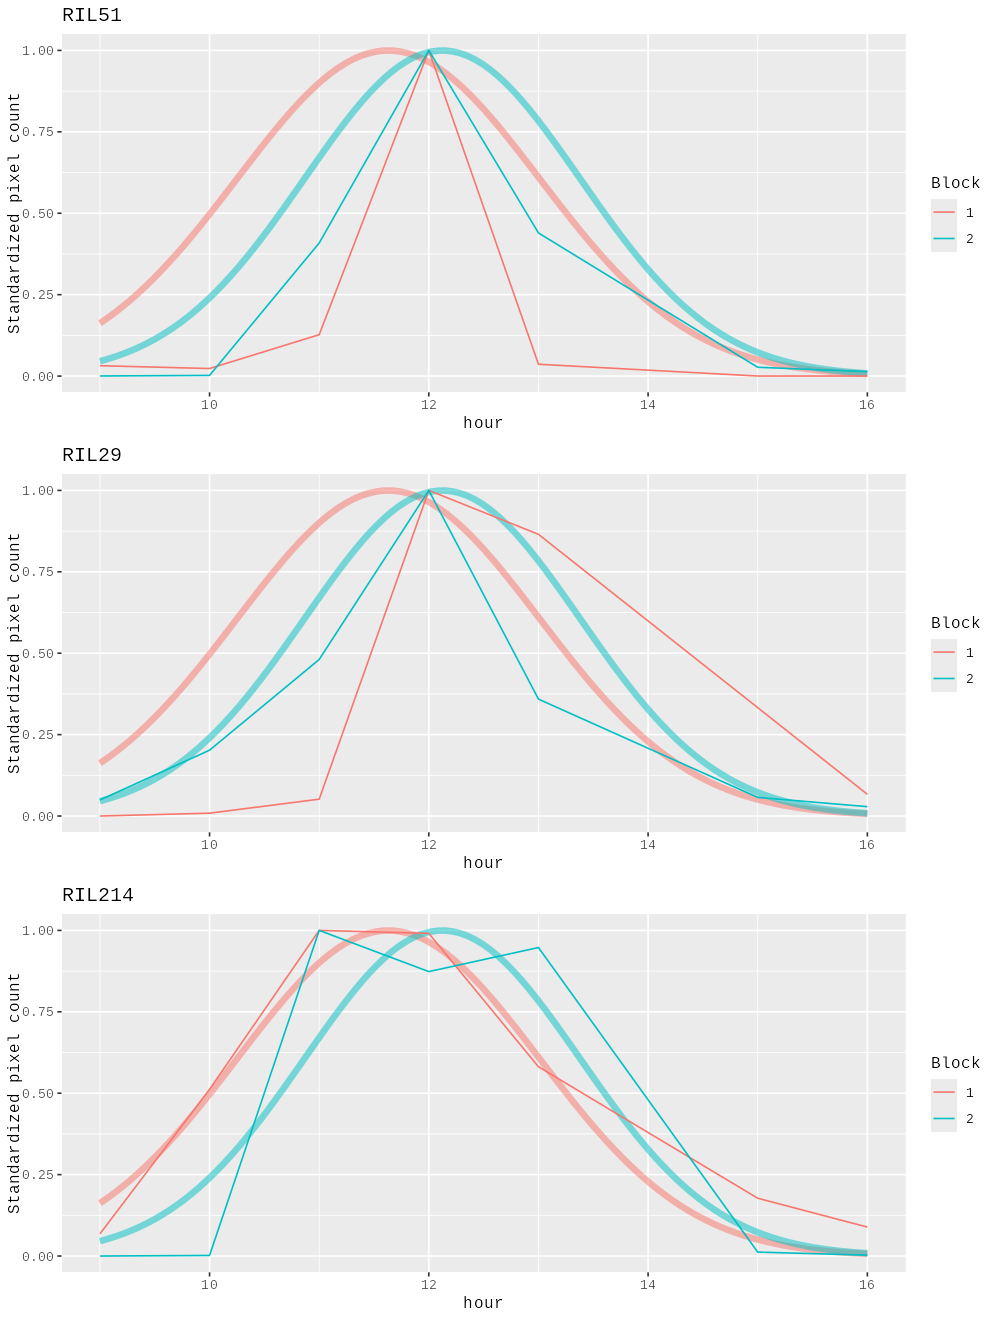

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/fot_curves.png'))

## Interpretation and validation record

- The SVM stage reproduces the authors' published behavior on their own bundled data: the radial SVM reaches ≈ 99% 10-fold CV accuracy, clearly above the naive threshold baseline's ~24% false-negative rate, and is robust across random splits (authors recorded 0.9879–0.9917).
- The Bayesian stage estimates per-plot peak floral opening times consistent with the authors' recorded values (peaks around 11.6–12.7 h); small numerical differences versus the authors' table are expected from MCMC sampling variation and the `rethinking`/`rstan` version difference (authors used rethinking 1.92 / rstan 2.19.3 on R 3.6, 2020).
- **Scope limits:** this demonstrates phenotype extraction only on the authors' published example data. The upstream orthomosaic/plot-polygon production (Pix4DMapper Pro / ArcMap), the 8.8 GB imagery, genotyping and QTL mapping are not reproduced. The authors' full-plot MCMC run ("hours") is reduced to their published demo subset.
- **Validation:** this notebook was executed top-to-bottom on a fresh Colab CPU runtime; all cell outputs are from that single run.

References: Han et al. 2020 (bioRxiv 2020.07.16.206953); author code rkbhan/FloralOpening@9069822; McElreath, *Statistical Rethinking* (rethinking).